# Against other codes

Every check in the regression suite is, in the end, self-referential about **conventions**. `scipy.linalg.expm` confirms that $U$ is the matrix exponential of the Hamiltonian — but of the Hamiltonian this library built. The standard oscillation formulas were transcribed from the same papers the builders were. A mixing-matrix ordering, a sign, or a unit conversion that was wrong *consistently* across the package would pass all of it.

This notebook compares against two things that would not: an independent external code, and a published closed form derived a different way.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## Two comparators

**[nuSQuIDS](https://github.com/arguelles/nuSQuIDS)** evolves the neutrino density matrix numerically, in C++. It shares no lineage with the closed-form SU($n$) expansions here, and it is configured from mixing *angles* and a density in g/cm³ rather than from a Hamiltonian — so agreement exercises `hamiltonians3nu` and `hamiltonians4nu` as much as the expansions.

Its values are **frozen** into `tests/nusquids_reference.json` rather than computed here. nuSQuIDS ships manylinux wheels and would install in CI, but a comparison that runs in CI is a dependency on somebody else's release cadence. `tests/nusquids_reference.py` regenerates it deliberately.

**Zaglauer–Schwarzer** (Z. Phys. C 40, 273 (1988)) give the exact eigenvalues of the matter Hamiltonian as roots of an explicit cubic in the vacuum parameters — never forming the matrix. That runs live, below, at any configuration and with no dependency.

In [2]:
import json

with open(os.path.join("..", "tests",
                       "nusquids_reference.json")) as handle:
    REF = json.load(handle)

print("nuSQuIDS version :", REF["nusquids_version"])
print("cases            :", len(REF["cases"]))
for case in REF["cases"]:
    print("   ", case["name"])

nuSQuIDS version : 1.13.3
cases            : 7
    3nu vacuum, 1 GeV, 1300 km
    3nu vacuum, 0.6 GeV, 295 km
    3nu matter rho=3, 1 GeV, 1300 km
    3nu matter rho=3, 5 GeV, 1300 km
    4nu vacuum, 1 GeV, 1300 km
    4nu vacuum, 0.5 GeV, 0.6 km
    4nu matter rho=3, 1 GeV, 1300 km


## The convention dictionary

Comparing two codes is mostly the work of matching what they mean, not what they compute. There are exactly two differences here, and **both are definitional** — neither is an error in either code.

In [3]:
C = REF["constants"]

# 1. The length unit
print("CONV_KM_TO_INV_EV")
print("  ours      : %.10e" % gd.CONV_KM_TO_INV_EV)
print("  nuSQuIDS  : %.10e   (= 1 km / hbar c)" % C["km"])
print("  relative  : %.2e"
      % abs(gd.CONV_KM_TO_INV_EV/C["km"] - 1.0))

# 2. The electron density behind V_CC
rho, ye = gd.DENSITY_MATTER_CRUST_G_PER_CM3, REF["electron_fraction"]
ne_theirs = rho*C["avogadro"]*ye/C["cm"]**3
vcc_theirs = np.sqrt(2.0)*C["GF"]*ne_theirs
print("\nV_CC at rho = %.1f g/cm^3" % rho)
print("  ours      : %.6e   (1 g / mean nucleon mass)"
      % gd.VCC_EARTH_CRUST)
print("  nuSQuIDS  : %.6e   (rho N_A Y_e)" % vcc_theirs)
print("  ratio     : %.5f  -> %.2f%%, the nuclear mass defect"
      % (vcc_theirs/gd.VCC_EARTH_CRUST,
         100*(vcc_theirs/gd.VCC_EARTH_CRUST - 1.0)))

CONV_KM_TO_INV_EV
  ours      : 5.0677300000e+09
  nuSQuIDS  : 5.0677307162e+09   (= 1 km / hbar c)
  relative  : 1.41e-07

V_CC at rho = 3.0 g/cm^3
  ours      : 1.135602e-13   (1 g / mean nucleon mass)
  nuSQuIDS  : 1.144870e-13   (rho N_A Y_e)
  ratio     : 1.00816  -> 0.82%, the nuclear mass defect


The length unit looks harmless at $1.4\times10^{-7}$, but it multiplies the **accumulated phase**. At 1300 km and 1 GeV that phase is some $2.5\times10^3$ radian; with an eV-scale sterile it is $10^4$. So a seventh-decimal-place constant becomes a fourth-decimal-place probability.

## The comparison

Every frozen case, computed both with our constants and with nuSQuIDS' — so the effect of matching is visible rather than asserted.

In [4]:
def ours(case, km, vcc, vnc):
    """This library's probabilities for one frozen case."""
    p = REF["parameters"]
    s = np.sin
    E = case["energy_gev"]*GEV
    L = case["baseline_km"]*km
    rho = case["density_g_cm3"]
    if case["n_flavors"] == 3:
        H0 = np.asarray(hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
            s(p["th12"]), s(p["th23"]), s(p["th13"]),
            p["dcp"], p["dm21"], p["dm31"]))
        H = (H0/E if rho is None else
             hamiltonians3nu.hamiltonian_3nu_matter(H0, E, vcc))
        return np.array(oscprob3nu.probabilities_3nu(
            H, L)).reshape(3, 3)
    H0 = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
        s(p["th12"]), s(p["th23"]), s(p["th13"]),
        s(p["th14"]), s(p["th24"]), s(p["th34"]),
        p["dcp"], p["dm21"], p["dm31"], p["dm41"])
    H = (H0/E if rho is None else
         hamiltonians4nu.hamiltonian_4nu_matter(H0, E, vcc, vnc))
    return np.array(oscprob4nu.probabilities_4nu(
        H, L)).reshape(4, 4)


def potentials(rho, matched):
    """(V_CC, V_NC) in either convention."""
    if rho is None:
        return None, None
    if not matched:
        scale = rho/gd.DENSITY_MATTER_CRUST_G_PER_CM3
        return (gd.VCC_EARTH_CRUST*scale,
                gd.VNC_EARTH_CRUST*scale)
    ye = REF["electron_fraction"]
    ne = rho*C["avogadro"]*ye/C["cm"]**3
    nn = rho*C["avogadro"]*(1.0 - ye)/C["cm"]**3
    return (np.sqrt(2.0)*C["GF"]*ne,
            -C["GF"]*nn/np.sqrt(2.0))


names, unmatched, matched_ = [], [], []
for case in REF["cases"]:
    theirs = np.array(case["probabilities"])
    rho = case["density_g_cm3"]
    a = np.max(np.abs(ours(case, gd.CONV_KM_TO_INV_EV,
                           *potentials(rho, False)) - theirs))
    b = np.max(np.abs(ours(case, C["km"],
                           *potentials(rho, True)) - theirs))
    names.append(case["name"])
    unmatched.append(a)
    matched_.append(b)

print("%-36s %11s %11s" % ("case", "our conv.", "matched"))
for n, a, b in zip(names, unmatched, matched_):
    print("%-36s %11.2e %11.2e" % (n, a, b))

case                                   our conv.     matched
3nu vacuum, 1 GeV, 1300 km              5.41e-07    2.22e-15
3nu vacuum, 0.6 GeV, 295 km             1.49e-08    1.38e-14
3nu matter rho=3, 1 GeV, 1300 km        2.40e-04    6.59e-12
3nu matter rho=3, 5 GeV, 1300 km        4.65e-05    1.55e-12
4nu vacuum, 1 GeV, 1300 km              9.80e-05    4.65e-11
4nu vacuum, 0.5 GeV, 0.6 km             1.36e-08    3.89e-16
4nu matter rho=3, 1 GeV, 1300 km        5.01e-04    2.35e-11


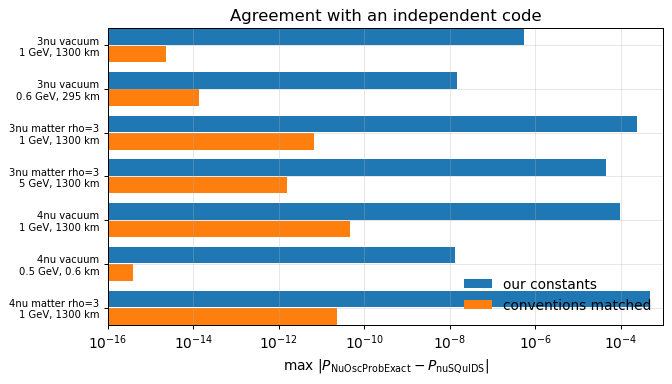

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))
y = np.arange(len(names))
ax.barh(y - 0.2, unmatched, height=0.38,
        label="our constants")
ax.barh(y + 0.2, matched_, height=0.38,
        label="conventions matched")
ax.set_yticks(y)
ax.set_yticklabels([n.replace(", ", "\n", 1) for n in names],
                   fontsize=8)
ax.set_xscale("log")
ax.set_xlim(1e-16, 1e-3)
ax.set_xlabel(r"max $|P_{\rm NuOscProbExact} - P_{\rm nuSQuIDS}|$")
ax.set_title("Agreement with an independent code")
ax.invert_yaxis()
ax.legend(loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

Matched, the two codes agree between $10^{-11}$ and $10^{-15}$ — round-off, for two implementations that share nothing. Everything to the left of that in the "our constants" bars is convention, not physics.

The **four-flavor rows** deserve their own note. `oscprob4nu` is new, and until this comparison it was validated only against `scipy.linalg.expm` and against its own three-flavor limit. It is now checked by an outside code: $3.9\times10^{-16}$ where the spectrum is benign, and $2.4\times10^{-11}$ where it is stiff — which is the accuracy `POLISH_ROOTS` documents, arrived at independently.

## Zaglauer–Schwarzer, live

The frozen data covers seven configurations. This covers **all** of them, with no dependency.

Zaglauer and Schwarzer give the eigenvalues of

$$M^2_{\rm eff} = U M^2 U^\dagger + \mathrm{diag}(A, 0, 0), \qquad A = 2EV_{CC}$$

as roots of an explicit cubic in the vacuum parameters and $A$ — the matrix is never formed. Comparing those against the spectrum of the Hamiltonian we *do* form tests the construction: the PMNS parametrization, where the potential is added, and the relative normalization of the two terms.

The $|U_{ei}|^2$ below come straight from the angles, not from `pmns_mixing_matrix`, so a mistake in our mixing matrix cannot cancel against itself.

In [6]:
def zaglauer_schwarzer(s12, s13, dm21, dm31, A):
    """Exact eigenvalues of M^2_eff, from the vacuum parameters."""
    c13sq = 1.0 - s13*s13
    ue1, ue2, ue3 = (1.0 - s12*s12)*c13sq, s12*s12*c13sq, s13*s13
    x = dm21 + dm31 + A
    y = dm21*dm31 + A*(dm21*(1.0 - ue2) + dm31*(1.0 - ue3))
    z = A*dm21*dm31*ue1
    p = y - x*x/3.0
    q = -2.0*x**3/27.0 + x*y/3.0 - z
    t = 2.0*np.sqrt(-p/3.0)
    th = np.arccos(np.clip(3.0*q/(p*t), -1.0, 1.0))
    return np.sort(t*np.cos((th + 2.0*np.pi*np.arange(3))/3.0)
                   + x/3.0)


VCC = gd.VCC_EARTH_CRUST
E_gev = np.logspace(-0.5, 2.0, 400)

tracks, deviations = [], []
for e in E_gev:
    E = e*GEV
    H = np.asarray(hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, E, VCC))
    mine = np.sort(np.linalg.eigvalsh(2.0*E*H))
    theirs = zaglauer_schwarzer(gd.S12_NO_BF, gd.S13_NO_BF,
                                gd.D21_NO_BF, gd.D31_NO_BF,
                                2.0*E*VCC)
    tracks.append(mine)
    deviations.append(np.max(np.abs(mine - theirs))
                      / np.max(np.abs(mine)))
tracks = np.array(tracks)
deviations = np.array(deviations)

print("worst relative deviation over the scan: %.2e"
      % deviations.max())

worst relative deviation over the scan: 1.34e-15


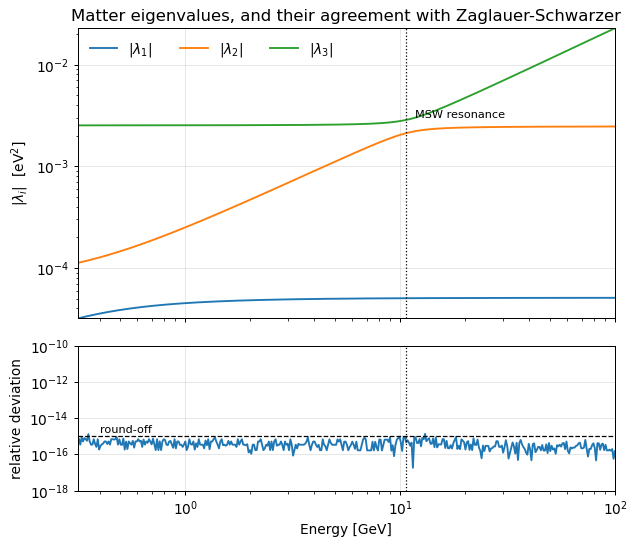

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.2),
                         sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

for i in range(3):
    axes[0].loglog(E_gev, np.abs(tracks[:, i]),
                   label=r"$|\lambda_%d|$" % (i + 1))
c2th13 = 1.0 - 2.0*gd.S13_NO_BF**2
E_res = gd.D31_NO_BF*c2th13/(2.0*VCC)/GEV
axes[0].axvline(E_res, color="k", ls=":", lw=1)
axes[0].text(E_res*1.1, 3e-3, "MSW resonance", fontsize=9)
axes[0].set_ylabel(r"$|\lambda_i|$  [eV$^2$]")
axes[0].set_title("Matter eigenvalues, and their agreement "
                  "with Zaglauer-Schwarzer")
axes[0].legend(ncol=3)

axes[1].loglog(E_gev, np.maximum(deviations, 1e-18), "-")
axes[1].axhline(1e-15, color="k", ls="--", lw=1)
axes[1].text(0.4, 1.6e-15, "round-off", fontsize=9)
axes[1].axvline(E_res, color="k", ls=":", lw=1)
axes[1].set_ylim(1e-18, 1e-10)
axes[1].set_xlim(E_gev[0], E_gev[-1])
axes[1].set_xlabel("Energy [GeV]")
axes[1].set_ylabel("relative deviation")
fig.tight_layout()
plt.show()

The agreement holds through the resonance, which is where the two upper eigenvalues come closest and any error in the construction would be most visible.

One transcription note, because it is the kind of mistake that usually produces a plausible wrong curve rather than an obvious one: the depressed cubic's constant term is $-2x^3/27 + xy/3 - z$. Written first with the signs of the first two terms flipped, it disagreed with the spectrum by 50% — large enough to be unmissable, which was luck. The corrected form is identical to the resolvent cubic already inside `oscprob4nu`, which is where it should have been checked against from the start.

## What this covers, and what it does not

Worth being precise, since "validated against an independent code" is easy to over-claim.

| Checked | By |
|---|---|
| $U$ is $e^{-iHL}$ | `scipy.linalg.expm`, in the suite |
| The Hamiltonian we build is the right one | nuSQuIDS, and Zaglauer–Schwarzer for the matter spectrum |
| Mixing-matrix conventions, $\theta_{23}$, $\delta_{CP}$ | nuSQuIDS, and the vacuum reference formulas |
| Four-flavor probabilities | nuSQuIDS, at 4e-11 to 4e-16 |
| Arbitrary matter configurations | Zaglauer–Schwarzer, live |

What is **not** covered: Zaglauer–Schwarzer eigenvalues are independent of $\theta_{23}$ and $\delta_{CP}$, since only the electron row of $U$ enters the matter term — and eigenvalues are not probabilities. The frozen nuSQuIDS set covers seven configurations, not the whole parameter space. And no external code here exercises `slabs` or `earth`, whose layered composition is checked internally against `expm` instead.